In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

print("Path to dataset files:", path)

 40%|████████████████████████████████▎                                               | 264M/653M [11:44<17:17, 393kB/s]


ChunkedEncodingError: ("Connection broken: ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)", ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

print("Path to dataset files:", path)

Resuming download from 276824064 bytes (408031848 bytes left)...
Resuming download to C:\Users\Anshika\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\13.archive (276824064/684855912) bytes left.


100%|███████████████████████████████████████████████████████████████████████████████| 653M/653M [04:59<00:00, 1.36MB/s]

Extracting files...


Path to dataset files: C:\Users\Anshika\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13


Dataset Shape: (20000, 5)
   Severity  Temperature  Humidity  Visibility        Weather
0         3         36.9      91.0        10.0     Light Rain
1         2         37.9     100.0        10.0     Light Rain
2         2         36.0     100.0        10.0       Overcast
3         3         35.1      96.0         9.0  Mostly Cloudy
4         2         36.0      89.0         6.0  Mostly Cloudy
After removing missing values: (19585, 5)


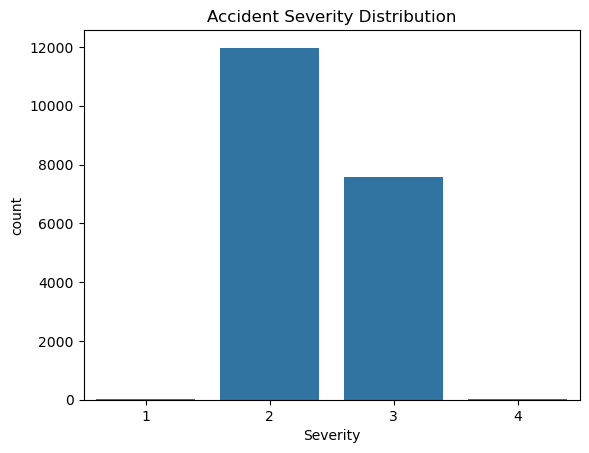

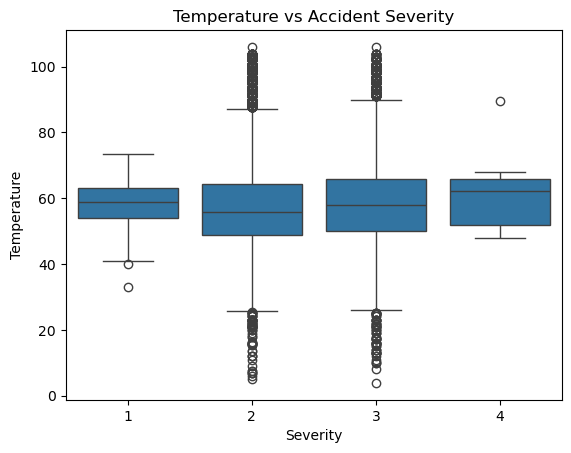

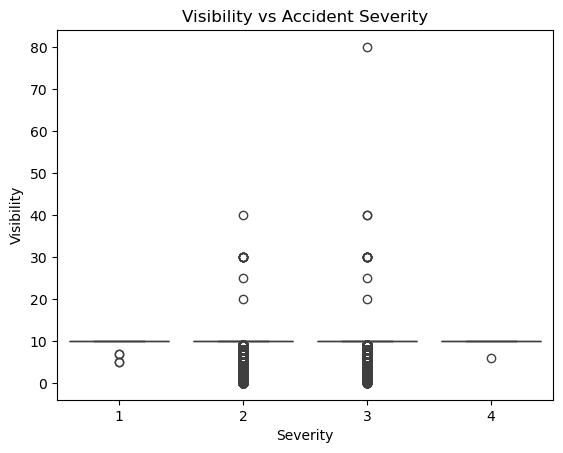

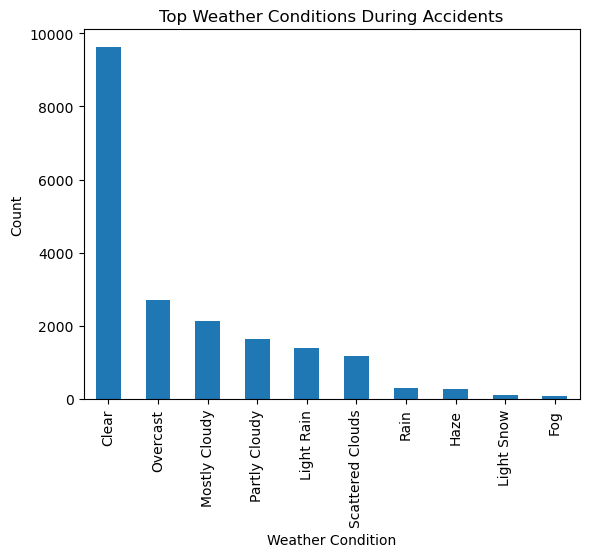

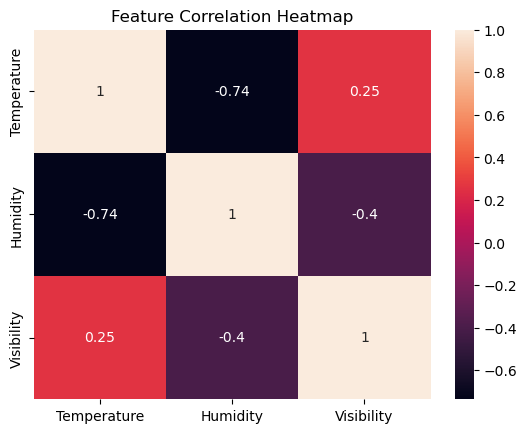


Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         7
           2       0.62      0.93      0.75      2376
           3       0.55      0.14      0.22      1532
           4       0.00      0.00      0.00         2

    accuracy                           0.62      3917
   macro avg       0.29      0.27      0.24      3917
weighted avg       0.59      0.62      0.54      3917



C:\Users\Anshika\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Anshika\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Anshika\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


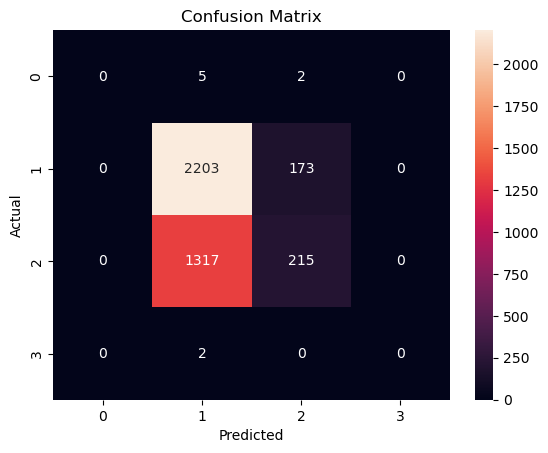

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1 Load Dataset (FAST)
# -----------------------------

path = r"C:\Users\Anshika\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13\US_Accidents_March23.csv"

df = pd.read_csv(
    path,
    nrows=20000,
    usecols=['Severity','Temperature(F)','Humidity(%)','Visibility(mi)','Weather_Condition']
)

# Rename columns
df.columns = ['Severity','Temperature','Humidity','Visibility','Weather']

print("Dataset Shape:", df.shape)
print(df.head())

# -----------------------------
# 2 Handle Missing Values
# -----------------------------

df.dropna(inplace=True)

print("After removing missing values:", df.shape)

# -----------------------------
# 3 Data Visualization
# -----------------------------

# Severity distribution
plt.figure()
sns.countplot(x='Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()

# Temperature vs severity
plt.figure()
sns.boxplot(x='Severity', y='Temperature', data=df)
plt.title("Temperature vs Accident Severity")
plt.show()

# Visibility vs severity
plt.figure()
sns.boxplot(x='Severity', y='Visibility', data=df)
plt.title("Visibility vs Accident Severity")
plt.show()

# Top weather conditions
top_weather = df['Weather'].value_counts().head(10)

plt.figure()
top_weather.plot(kind='bar')
plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.show()

# Correlation heatmap
plt.figure()
sns.heatmap(df[['Temperature','Humidity','Visibility']].corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# -----------------------------
# 4 Encode Categorical Data
# -----------------------------

le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])

# -----------------------------
# 5 Feature Selection
# -----------------------------

X = df[['Temperature','Humidity','Visibility','Weather']]
y = df['Severity']

# -----------------------------
# 6 Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 7 Train Model
# -----------------------------

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 8 Prediction
# -----------------------------

pred = model.predict(X_test)

# -----------------------------
# 9 Model Evaluation
# -----------------------------

print("\nClassification Report:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()